In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Generate simple dataset
# You are synthetically generating data for a linear regression problem.
# y=4+3x+noise

# Fix random numbers so results are same every time you run
np.random.seed(0)

# Generate 100 random values of X between 0 and 2
# shape = (100, 1) → 100 samples, 1 feature
X = 2 * np.random.rand(100, 1)

# Generate output using linear relation:
# y = 4 + 3X + noise
# np.random.randn → adds Gaussian noise (mean=0, std=1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Assign to training variables
X_train = X
y_train = y

# Print values (just to inspect data)
print("First 5 X values:\n", X[:5])
print("First 5 y values:\n", y[:5])

First 5 X values:
 [[1.09762701]
 [1.43037873]
 [1.20552675]
 [1.08976637]
 [0.8473096 ]]
First 5 y values:
 [[6.12773118]
 [9.19196269]
 [8.0822427 ]
 [5.73305541]
 [8.03018099]]


In [ ]:
class LinearRegressionScratch:
    def __init__(self, eta=0.01, epochs=1000, lam=0, reg_type=None):
        # Learning rate (how big each step is)
        self.eta = eta
        
        # Number of iterations for gradient descent
        self.epochs = epochs
        
        # Regularization strength (λ)
        self.lam = lam
        
        # Type of regularization: 'ridge' or 'lasso'
        self.reg_type = reg_type
        
        # Store loss values for plotting
        self.train_loss = []
        
        # Parameters (θ) → will be learned
        self.theta = None
        
        # Store θ at each step (optional analysis)
        self.theta_history = []

    def compute_loss(self, X, y):
        # n = number of samples
        n = X.shape[1]

        # Predictions: h = X^T * θ
        # shape: (n, 1)
        h = np.dot(X.T, self.theta)

        # Error term: (prediction - actual)
        term = h - y.reshape(n, 1)

        # MSE Loss = (1/n) * (error^2)
        loss = (1 / n) * np.dot(term.T, term)

        # Add regularization penalty

        # Ridge: λ * Σ(θ^2)
        if self.reg_type == 'ridge':
            loss += self.lam * np.sum(self.theta**2)

        # Lasso: λ * Σ(|θ|)
        elif self.reg_type == 'lasso':
            loss += self.lam * np.sum(np.abs(self.theta))

        # Convert from array to scalar
        return loss.item()

    def fit(self, X, y):
        # Transpose so shape becomes (features, samples) -> m*n
        X = X.T
        m, n = X.shape   # m = features, n = samples

        # Add bias row (all 1s)
        # Now X shape: (m+1, n) 
        X = np.vstack( (np.ones((1, n)), X) )

        # Ensure y is column vector (n, 1)
        y = y.reshape(n, 1)

        # Initialize θ = zeros → shape (m+1, 1)
        self.theta = np.zeros((m + 1, 1))

        # Gradient Descent loop
        for _ in range(self.epochs):
            # Predictions
            h = np.dot(X.T, self.theta)   # (n, 1)

            # Gradient of MSE loss
            # (m+1, 1)
            gradient = (2 / n) * np.dot(X, (h - y))

            # Add regularization gradient
            # Ridge derivative: 2λθ
            if self.reg_type == 'ridge':
                gradient += 2 * self.lam * self.theta

            # Lasso derivative: λ * sign(θ)
            elif self.reg_type == 'lasso':
                gradient += self.lam * np.sign(self.theta)

            # Update rule: θ = θ - η * gradient
            self.theta -= self.eta * gradient

            # Store loss for analysis
            self.train_loss.append(self.compute_loss(X, y))

            # Store θ history (optional)
            self.theta_history.append(self.theta.copy())

    def predict(self, X):
        # X shape: (samples, features)
        n, m = X.shape

        # Transpose → (features, samples)
        X = X.T

        # Add bias row
        X = np.vstack((np.ones((1, X.shape[1])), X))

        # Return predictions → flatten to 1D
        return np.dot(X.T, self.theta).flatten()

In [ ]:
# Different values of regularization strength (λ)
lambdas = [0, 0.01, 0.1, 1, 10]

# Dictionary to store trained models for each λ
# Key = λ, Value = trained model object
ridge_models = {}

# Dictionary to store results (theta and final loss)
# Key = λ, Value = (theta, loss)
ridge_results = {}

# Loop over each λ value
for lam in lambdas:
    # Create a new model with current λ and Ridge regularization
    model = LinearRegressionScratch (lam=lam, reg_type='ridge')
    
    # Train the model using gradient descent
    model.fit(X_train, y_train)

    # Store the trained model (useful later for prediction/plotting)
    ridge_models[lam] = model

    # Store final parameters and final training loss
    # model.train_loss[-1] → last value = final loss after training
    ridge_results[lam] = (model.theta, model.train_loss[-1])

    # Print results for analysis
    print(f"Ridge λ={lam}")
    
    # .ravel() converts column vector [[a],[b]] → [a, b]
    print("Theta:", model.theta.ravel())
    
    # Final training loss
    print("Final Loss:", model.train_loss[-1])
    
    # Separator for readability
    print("-"*40)

    # “As λ increases, the regularization penalty forces parameters toward zero, reducing model complexity. 
    # This leads to higher training loss and eventually underfitting. 
    # For λ = 0, we get the best fit, while large λ values oversimplify the model.”

Ridge λ=0
Theta: [4.18679917 2.9998363 ]
Final Loss: 0.9927981764824189
----------------------------------------
Ridge λ=0.01
Theta: [4.12688191 3.0206519 ]
Final Loss: 1.2570079968615193
----------------------------------------
Ridge λ=0.1
Theta: [3.72479361 3.09972403]
Final Loss: 3.4857144819389534
----------------------------------------
Ridge λ=1
Theta: [2.3693889  2.42211234]
Final Loss: 18.1863183250169
----------------------------------------
Ridge λ=10
Theta: [0.58479257 0.63069681]
Final Loss: 44.40529413041933
----------------------------------------


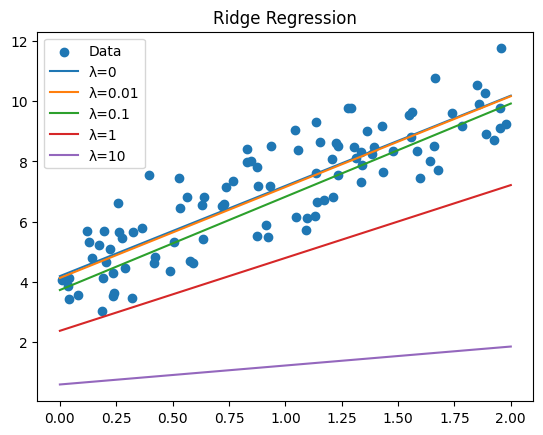

In [ ]:
plt.scatter(X_train, y_train, label="Data")

X_plot = np.linspace(0, 2, 100).reshape(100, 1)

for lam in lambdas:
    y_pred = ridge_models[lam].predict(X_plot)
    plt.plot(X_plot, y_pred, label=f"λ={lam}")

plt.title("Ridge Regression")
plt.legend()
plt.show()

# “As λ increases, the regression line becomes flatter because Ridge penalizes large weights. 
# This reduces model complexity but leads to underfitting at high λ values.”

# Left side (λ small) → overfitting risk
# Middle → best tradeoff
# Right side (λ large) → underfitting

In [12]:
lasso_models = {}
lasso_results = {}

for lam in lambdas:
    model = LinearRegressionScratch(lam=lam, reg_type='lasso')
    model.fit(X_train, y_train)

    lasso_models[lam] = model
    lasso_results[lam] = (model.theta, model.train_loss[-1])

    print(f"Lasso λ={lam}")
    print("Theta:", model.theta.ravel())
    print("Final Loss:", model.train_loss[-1])
    print("-"*40)

Lasso λ=0
Theta: [4.18679917 2.9998363 ]
Final Loss: 0.9927981764824189
----------------------------------------
Lasso λ=0.01
Theta: [4.18265111 2.99894865]
Final Loss: 1.0646775516415676
----------------------------------------
Lasso λ=0.1
Theta: [4.14531857 2.99095972]
Final Loss: 1.709322049709806
----------------------------------------
Lasso λ=1
Theta: [3.77199312 2.91107047]
Final Loss: 7.931049072346613
----------------------------------------
Lasso λ=10
Theta: [0.03873866 2.11217792]
Final Loss: 47.676523494156996
----------------------------------------


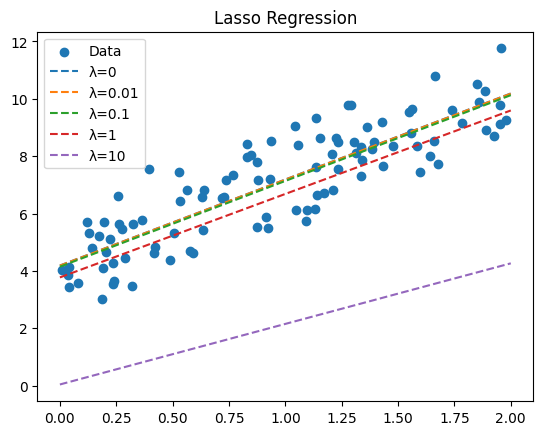

In [ ]:
plt.scatter(X_train, y_train, label="Data")

for lam in lambdas:
    y_pred = lasso_models[lam].predict(X_plot)
    plt.plot(X_plot, y_pred, linestyle='--', label=f"λ={lam}")

plt.title("Lasso Regression")
plt.legend()
plt.show()

# In this graph, Lasso behaves similarly to Ridge because we have only one feature. 
# However, unlike Ridge, Lasso uses an L1 penalty which can drive coefficients exactly to zero, enabling feature selection in higher-dimensional data.”

In [ ]:
# # Example learned parameters (for λ = 0)
# # θ = [4.18, 2.99]

# OBSERVATIONS:

# 1. Effect of λ on Model Complexity:
# - When λ is small (close to 0), the model behaves like normal linear regression.
#   It fits the training data very closely, capturing even small variations (including noise).
#   Hence, the model is more complex.

# - As λ increases, a penalty is applied on the magnitude of parameters.
#   This forces the model to reduce the slope and intercept, resulting in a smoother and simpler line.

# - For very large λ values, the model becomes overly simple (almost flat line),
#   which means it fails to capture the underlying pattern in the data. ->  may underfit


# 2. Effect of λ on Parameter Magnitude:
# - In Ridge Regression (L2 regularization), the penalty term is λ * Σ(θ^2).
#   This continuously shrinks the parameter values toward zero, but they never become exactly zero.

# - In Lasso Regression (L1 regularization), the penalty term is λ * Σ(|θ|).
#   This can force some parameters to become exactly zero, effectively removing their influence.

# - As λ increases, both slope (θ1) and intercept (θ0) decrease in magnitude.
#   In this implementation, even the bias term is regularized, so it also shrinks.


# 3. Effect on Overfitting and Underfitting:
# - When λ = 0:
#   There is no regularization, so the model may overfit the data,
#   meaning it captures noise along with the actual pattern.

# - For small to moderate λ values:
#   The model achieves a good balance between fitting the data and keeping parameters small.
#   This improves generalization and reduces overfitting.

# - For large λ values:
#   Regularization dominates, forcing parameters to be very small.
#   The model becomes too simple and cannot fit the data properly, leading to underfitting.


# CONCLUSION:
# - λ controls the trade-off between data fitting and model simplicity.
# - Small λ → better fit but risk of overfitting.
# - Large λ → simpler model but risk of underfitting.
# - An optimal λ gives the best generalization performance.
# """)